In [1]:
from tabnanny import verbose
from typing import Callable
import quantecon
from quantecon.markov import tauchen
import numpy as np
from numba import njit
import quantecon
import interpolation
from numba import guvectorize, float64
from dataclasses import dataclass
import time

# TODO
- 外挿を避ける?

# Done

- 総資本ストック供給をAmesh*sdに戻す
- 均衡確認を追加

## settings.py

In [2]:
@njit
def maliar_grid(a_min, a_max, N, theta):
    a_grid = np.empty(N)
    for i in range(1,N+1):
        a_grid[i-1] = a_min + (a_max - a_min)*((i-1)/(N-1))**theta
        
    return a_grid

# 解く問題の設定を行う（パラメータ, グリッド, 効用関数や生産関数）
# モデルを変更する場合にはここを修正
class Setting:

    def __init__(self,
                beta=0.99,                       # 割引因子
                gamma=1,                         # 相対的リスク回避度(異時点間の代替弾力性の逆数)
                b=0,                             # 内生的な状態変数の最小値, 借入制約
                a_max=16,                        # 内生的な状態変数の最大値
                na=21,                           # 内生的な状態変数のグリッド数
                na_sd=21,
                mu=0,                            # 外生変数のAR(1)過程の定数項
                rho=0.6,                         # 外生変数のAR(1)過程の慣性
                sigma=0.4,                       # 外生変数のAR(1)過程のショック項の標準偏差
                nz = 11,                         # 外生変数のグリッド数
                w=1.0,                           # 賃金の初期化
                r0 = 0.03,                       # 利子率の初期化
                alpha = 0.36,                    # 資本分配率
                delta = 0.05,                    # 固定資本減耗率
                lambdaPF = 1,                    # 政策関数の更新度
                tau = 0.1,                       # 資本所得課税率
                ):

        # パラメータを設定する
        self.r = r0
        self.beta = beta
        self.b = b
        self.gamma = gamma
        self.alpha = alpha
        self.delta = delta
        self.sigma = sigma
        self.rho = rho
        self.na = na
        self.na_sd = na_sd
        self.nz = nz
        self.a_min = -b
        self.a_max = a_max
        self.lambdaPF = lambdaPF
        self.tau = tau

        # 外生変数の遷移確率とグリッドを設定する
        mc = quantecon.markov.approximation.rouwenhorst(nz, rho, sigma, mu)
        # mc = tauchen(nz, rho, sigma, mu, n_std = 2)
        self.Pz = np.array(mc.P)
        if mc.state_values is None:
            raise ValueError("mc.state_values is None, cannot apply np.exp.")
        self.z_grid = np.exp(mc.state_values)

        # 生産性の定常分布を求める
        muZ_old = np.ones(len(self.z_grid)) / len(self.z_grid)

        tol=1E-11
        maxit=100^4

        for it in range(maxit):
            muZ_new = muZ_old @ self.Pz
            if np.max(np.abs(muZ_new - muZ_old)) < tol: break
            muZ_old = muZ_new

        # 総労働供給を求める
        Lbar = sum(muZ_new * self.z_grid)

        # 総労働供給を1に基準化する
        self.z_grid = self.z_grid / Lbar

        Lbar = sum(muZ_new * self.z_grid)

        self.Lbar = Lbar

        # 内生的な状態変数のグリッドを設定する
        # a_grid = np.linspace(-b, a_max, na)
        a_grid = maliar_grid(-b, a_max, na, theta = 2.0)
        self.a_grid = a_grid

        # 賃金を設定
        self.w = w

        # 政策関数の更新度を設定する
        self.lambdaPF = lambdaPF

        # CRRA型効用関数と限界効用を定義する
        gamma = self.gamma
        if gamma == 1:
            self.utility = np.log
            self.mutility: Callable[[float], float] = njit(lambda x: 1 / x)
        else:
            self.utility = njit(lambda x: x**(1-gamma) / (1 - gamma))
            self.mutility = njit(lambda x: x**(-gamma))


        # 政策関数の初期値を定義する
        z_grid = self.z_grid
        hfun_old = np.empty((len(a_grid), len(z_grid)))
        for i_a, a in enumerate(a_grid):
            for i_z, z in enumerate(z_grid):
                c_max = 0.5* ((1+r0) * a + z + b)
                hfun_old[i_a, i_z] = c_max
        self.hfun_old = hfun_old


        # 資本所得税の初期化
        self.Xi = 0.0

## policy_function.py（政策関数の計算のための関数）

In [3]:
# 線形補間を効率的に行うコード（interpolationパッケージのinterpでは正しい結果が得られなかった）
# I took this function from state-space Jacobian package
# @guvectorize(['void(float64[:], float64[:], float64[:], float64[:])'], '(n),(nq),(n)->(nq)')
@njit
def interpolate_y(x, xq, y, yq):
    """Efficient linear interpolation exploiting monotonicity.
    Complexity O(n+nq), so most efficient when x and xq have comparable number of points.
    Extrapolates linearly when xq out of domain of x.
    Parameters
    ----------
    x  : array (n), ascending data points
    xq : array (nq), ascending query points
    y  : array (n), data points
    Returns
    ----------
    yq : array (nq), interpolated points
    """
    nxq, nx = xq.shape[0], x.shape[0]

    xi = 0
    x_low = x[0]
    x_high = x[1]
    for xqi_cur in range(nxq):
        xq_cur = xq[xqi_cur]
        while xi < nx - 2:
            if x_high >= xq_cur:
                break
            xi += 1
            x_low = x_high
            x_high = x[xi + 1]

        xqpi_cur = (x_high - xq_cur) / (x_high - x_low)
        yq[xqi_cur] = xqpi_cur * y[xi] + (1 - xqpi_cur) * y[xi + 1]



# 特定のアルゴリズムを実行して政策関数を更新する関数を出力する
# FOCを変更する場合やアルゴリズムを変更する場合はここを修正

# 今期の状態変数について繰り返し記号はi, 来期の状態変数について繰り返し記号はj

def TimeIteration(hp: Setting): # hpはSettingクラスからつくられるインスタンス

    # インスタンスからローカル変数を定義する
    r, beta, b, mutility, w = hp.r, hp.beta, hp.b, hp.mutility, hp.w
    a_grid, z_grid, Pz, tau, Xi = hp.a_grid, hp.z_grid, hp.Pz, hp.tau, hp.Xi

    @njit
    def FOCs(c, a, z, i_z, hfun):

        # 制約式から次期の内生的な状態変数を計算する
        aprime =np.array([(1+(1-tau)*r) * a + w*z - c + Xi])

        expectation = 0
        for j_z in range(len(z_grid)):
            # 政策関数の候補を補間して次期の制御変数を計算する
            # cprime = interpolation.interp(a_grid, hfun[:, j_z], aprime)
            tmp = np.empty(1, dtype=np.float64)
            interpolate_y(a_grid, aprime, hfun[:, j_z], tmp)
            cprime = tmp[0]
            if cprime is None:
                raise ValueError("interp returned None, but a float is expected.")

            # オイラー方程式の右辺を計算する
            expectation += mutility(cprime) * Pz[i_z, j_z]

        rhs = max((1 + (1-tau)*r) * beta * expectation, mutility((1+(1-tau)*r) * a + w*z + b + Xi))

        FOC_diff = mutility(c) - rhs

        return FOC_diff


    @njit
    def UpdatePF(h_old):

        h_new = np.empty_like(h_old)
        for i_a, a in enumerate(a_grid):
            for i_z, z in enumerate(z_grid):
                # 第3引数は初期値
                c_star = quantecon.optimize.root_finding.brentq(FOCs, 1e-8, (1+(1-tau)*r) * a + w*z + b, args=(a, z, i_z, h_old)).root
                h_new[i_a, i_z] = c_star

        return h_new

    return UpdatePF





# メイン関数：特定のアルゴリズムでiterationを行い、問題を解く関数
# 基本的には変更する必要がない

def SolveProblem(hp,               # Settingクラスからつくられるインスタンス
                Algorithm,         # アルゴリズムを指定
                tol=1e-4,          # 許容繰り返し誤差
                max_iter=10000,     # iteration回数の最大値
                verbose=True,      # 進捗を表示するかどうか
                print_skip=25):    # 進捗を何回ごとに表示するか


    # インスタンスからローカル変数を定義する
    # R, beta, b, mutility = hp.R, hp.beta, hp.b, hp.mutility
    # a_grid, z_grid, Pz = hp.a_grid, hp.z_grid, hp.Pz
    lambdaPF = hp.lambdaPF
    hfun_old = hp.hfun_old

    # チェックのために外生変数のグリッドと遷移確率を表示する
    # print(f"About exogenous variables:")
    # print(f"grid is {z_grid}.")
    # print(f"Transition matrix is {Pz}.")



    # 政策関数を更新する関数を取得する
    UpdatePF = Algorithm(hp)

    # iterationを行い、問題を解く
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:

        # 政策関数を更新する
        hfun_new_tilde = UpdatePF(hfun_old)

        # 古い政策関数と加重平均する
        hfun_new = lambdaPF*hfun_new_tilde + (1-lambdaPF)*hfun_old

        error = np.max(np.abs(hfun_new-hfun_old))
        i += 1
        if verbose and i % print_skip == 0:      # 進捗をprint_skip回ごとに表示する
            print(f"PF Error at iteration {i} is {error}.")
        hfun_old = hfun_new

    if i == max_iter:
        print("Failed to converge!")

    if verbose and i < max_iter:
        print(f"\nConverged in {i} iterations.")

    return hfun_new

## stationary_dist_fast.py(定常分布の計算のための関数)

In [4]:
@njit
def gridlookup2(x0, xgrid):
    nx = np.shape(xgrid)[0]
    ix = 0
    for jx in range(nx):
        if x0 <= xgrid[jx]:
            break
        ix += 1
    ix = min(max(1, ix), nx-1)
    return ix - 1

#sd = solve_sd(sd_grid, len(hp.a_grid), len(hp.z_grid),len(a_grid_sd),a_grid, a_grid_sd, hp.Pz, hfun_aprime)


@njit
def solve_sd(mu0: np.ndarray,
                        na: int,
                        nz: int,
                        na_sd: int,    # mu0.shape[0]のこと
                        agrid: np.ndarray,
                        agrid_sd: np.ndarray,
                        Pz: np.ndarray,
                        pfgrid: np.ndarray,
                        critmu: float = 1e-6):

    # -1. 政策関数の行列を補間して、行数を na 個から na_sd 個に変える
    # pfgrid -> pfgrid_new
    pfgrid_new = np.empty((na_sd,nz))              # 空の箱を用意
    for z_index in range(nz):
        aprime_new = np.empty(na_sd)
        interpolate_y(agrid, agrid_sd, pfgrid[:, z_index], aprime_new)
        pfgrid_new[:,z_index] = aprime_new


    # 0. transition matrixを計算
    G = np.zeros((na_sd*nz,na_sd*nz))
    weight = np.zeros((na_sd,nz))

    for iz in range(nz):
        for ia in range(na_sd):

            # 政策関数 pfgrid[ia, iz] に合わせる
            aprime = pfgrid_new[ia, iz]


            if aprime < agrid_sd[0]:
                weight[ia, iz] = 1.0
                jtilde = 0
            elif aprime > agrid_sd[-1]:
                weight[ia, iz] = 0
                jtilde = na_sd - 2
            else:
                # aprimeが落ちる区間の左端のグリッドのインデックスを探す
                jtilde = gridlookup2(aprime, agrid_sd)
                # 重み weight[ia, iz] に格納
                weight[ia, iz] = (agrid_sd[jtilde+1] - aprime) / (agrid_sd[jtilde+1] - agrid_sd[jtilde])

            # スタックしたときの現在の状態のインデックスを計算
            i_s = iz * na_sd + ia

            # 次期外生状態 jz でループ
            for jz in range(nz):

                # スタックしたときの次期の状態のインデックスを計算
                j_s  = jz * na_sd + jtilde

                # 遷移確率行列 G に代入
                #   - Pe[iz, jz] : 現在 iz から次期 jz への外生ショックの遷移確率
                G[i_s, j_s ] += weight[ia, iz]   * Pz[iz, jz]
                G[i_s, j_s + 1] += (1.0 - weight[ia, iz]) * Pz[iz, jz]


    diffmu = 1.0e4
    mu1    = np.zeros((na_sd, nz))

    # 分布の初期値をスタックしてベクトル化
    mu0 = mu0.T.flatten()

    while diffmu > 1e-6:

        # 1. 分布の更新 : dist_new = G' * dist
        mu1 = G.T @ mu0

        # 2. 収束判定
        diffmu = np.max(np.abs(mu1 - mu0))

        # 3. normalizeして次のループへ
        mu0 = mu1 / np.sum(mu1)

    sd = mu0.reshape(nz, na_sd).T
    return sd


## equilibrium.py(実行部分を関数化)

In [5]:
@dataclass
class Equilibrium:
    """ Equilibrium of the model
    """
    Ld: float
    Ls: float
    Kd: float
    Ks: float
    Y: float
    C: float
    r_star: float
    w_star: float
    labor_market_error: float
    goods_market_error: float
    capital_market_error: float

@dataclass
class Result:
    """ Result of equilibrium
    """
    eq: Equilibrium
    hfun_c: np.ndarray
    hfun_a: np.ndarray
    sd: np.ndarray
    converge_path: np.ndarray
    loop: int
    hp: Setting

In [6]:

def search_equilibrium(hp: Setting, lambdaR: float,DEBUG_MODE = False, tol = 1e-10) -> Result:
    """ Search equilibrium
    """


    converge_path = np.empty(0)

    diff = 1
    loop = 0
    while abs(diff) > tol:
        loop += 1

        # ローカル変数を定義
        alpha = hp.alpha #TODO: while文の外で良い
        delta = hp.delta
        r = hp.r
        na = hp.na
        nz = hp.nz
        tau = hp.tau

        # 1. 企業の利潤最大化条件から 総資本需要 K0d, 賃金 wage を求める
        Kd: float = ((r + delta) / alpha) ** (1 / (alpha - 1)) * hp.Lbar
        wage = (1 - alpha) * ((Kd/hp.Lbar) ** alpha) # 賃金の情報を更新
        hp.w = wage
        hp.Xi = tau * r * Kd # 資本所得税の合計

        # 2. 個人の最適化問題を解いて 政策関数を求める
        hfun_c = SolveProblem(hp,TimeIteration, verbose=DEBUG_MODE)

        # 3. 定常分布を求める
        # hfun_c から 時期のアセット aの政策関数を求める
        hfun_aprime = np.empty((na, nz))
        a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij') # ユニバーサル関数を使用するためのグリッドを生成
        hfun_aprime = (1+(1-tau)*r) * a_mesh + wage * z_mesh - hfun_c

        # 定常分布用のグリッドを用意
        a_grid_sd = np.linspace(-hp.b, hp.a_grid[-1], hp.na_sd)

        # 定常分布の初期値を定義する
        sd_grid = np.full((len(a_grid_sd), nz), 1.0 / (len(a_grid_sd) * nz)) # 各グリッドの初期値を均等に設定
        # sd_grid = np.full((na, nz), 1.0 / (na * nz)) # 各グリッドの初期値を均等に設定
        # sd = sd_iteration(sd_grid, hfun_aprime, hp.a_grid, hp.Pz)
        sd = solve_sd(sd_grid, len(hp.a_grid), len(hp.z_grid), len(a_grid_sd), hp.a_grid, a_grid_sd, hp.Pz, hfun_aprime)
        # sd = solve_sd(sd_grid, na, nz, hp.a_grid, hp.Pz, hfun_aprime)

        # 4. 総資本供給と総資本需要の差分を計算
        Amesh, _ = np.meshgrid(a_grid_sd, hp.z_grid, indexing='ij')
        # 総資本ストック供給 K_s の計算
        Ks = np.sum(Amesh * sd)
        print("Ks: ", Ks)
        
        diff = (Ks - Kd)
        converge_path = np.append(converge_path, diff)
        if DEBUG_MODE:
            print("loop: ", loop)
            print("r: ", r, ", Ks: ", Ks, ", diff: ", diff)

        r = r -  lambdaR * diff
        hp.r = r # r0を更新

    hfun_c_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    for iz in range(len(hp.z_grid)):
        interpolate_y(hp.a_grid, a_grid_sd, hfun_c[:, iz], hfun_c_interp[:, iz])

    # 各市場の均衡
    Ld = (hp.w / ((1 - hp.alpha) * Kd ** hp.alpha)) ** (-1 / hp.alpha)
    Labor_market_error = Ld - hp.Lbar
    Y = Kd ** hp.alpha * Ld ** (1 - hp.alpha)
    C = np.sum(hfun_c_interp * sd) 
    goods_market_error = Y - C - hp.delta * Kd
    capital_market_error = diff
    
    hp.r = r + lambdaR * diff # 最後のループで更新されたrを使う
    return Result(eq=Equilibrium(Ld=Ld, Ls=hp.Lbar, Kd=Kd, Ks=Ks, Y=Y, C=C,
                r_star=hp.r, w_star=hp.w,
                labor_market_error=Labor_market_error,
                goods_market_error=goods_market_error,
                capital_market_error=capital_market_error),
                hfun_c=hfun_c, hfun_a=hfun_aprime, sd=sd,
                converge_path=converge_path, loop=loop, hp=hp)

## main.py

In [7]:
loops = 1
times = np.empty(loops)
r_stars = np.empty(loops)
k_star = np.empty(loops)
w_star = np.empty(loops)
for i in range(loops):
    start = time.time()
    hp = Setting(beta=0.96, gamma=3, rho=0.6, sigma=0.4, 
                alpha=0.36, delta=0.08, b=3, a_max=45,
                nz = 7, na = 300, na_sd=800, r0 = 0.03, tau = 0.0) # brent法でエラーが出ないようにwの初期値を0以外に設定
    result = search_equilibrium(hp, lambdaR = 0.002, DEBUG_MODE= True)
    end = time.time()

    times[i] = (end - start)
    r_stars[i] = result.eq.r_star
    k_star[i] = result.eq.Ks
    w_star[i] = result.eq.w_star

print(f"TIME: {np.mean(times)}({np.std(times)})")
print(f"r_star: {np.mean(result.eq.r_star)}({np.std(result.eq.r_star)})")
print(f"K_star: {np.mean(result.eq.Ks)}({np.std(result.eq.Ks)})")
print(f"w_star: {np.mean(result.eq.w_star)}({np.std(result.eq.w_star)})")

/var/folders/y2/hwl07kg14b31nb5s126cjc8m0000gn/T/ipykernel_62393/2382395730.py:50: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = quantecon.markov.approximation.rouwenhorst(nz, rho, sigma, mu)


PF Error at iteration 25 is 0.06764740451769669.
PF Error at iteration 50 is 0.013949716329400008.
PF Error at iteration 75 is 0.004308093420788417.
PF Error at iteration 100 is 0.0014761589655316598.
PF Error at iteration 125 is 0.0005092168913263251.
PF Error at iteration 150 is 0.00016939033200280562.

Converged in 162 iterations.
Ks:  7.187713093976662
loop:  1
r:  0.03 , Ks:  7.187713093976662 , diff:  0.811738367738279
PF Error at iteration 25 is 0.06765164433601267.
PF Error at iteration 50 is 0.013933000363590242.
PF Error at iteration 75 is 0.0042775696031003285.
PF Error at iteration 100 is 0.00144025700913053.
PF Error at iteration 125 is 0.0004784698103792451.
PF Error at iteration 150 is 0.00014984341020252145.

Converged in 159 iterations.
Ks:  6.121883326717455
loop:  2
r:  0.028376523264523442 , Ks:  6.121883326717455 , diff:  -0.40395611650150354
PF Error at iteration 25 is 0.06765219043579052.
PF Error at iteration 50 is 0.013944307468344519.
PF Error at iteration 75 

In [8]:
# 均衡の誤差を表示
print(f"Labor market error: {result.eq.labor_market_error}")
print(f"Goods market error: {result.eq.goods_market_error}")
print(f"Capital market error: {result.eq.capital_market_error}")

Labor market error: 4.440892098500626e-16
Goods market error: -0.005413733328915926
Capital market error: -6.73345823543059e-11


In [9]:
# resultの変数の種類
result.__dict__.keys()

dict_keys(['eq', 'hfun_c', 'hfun_a', 'sd', 'converge_path', 'loop', 'hp'])

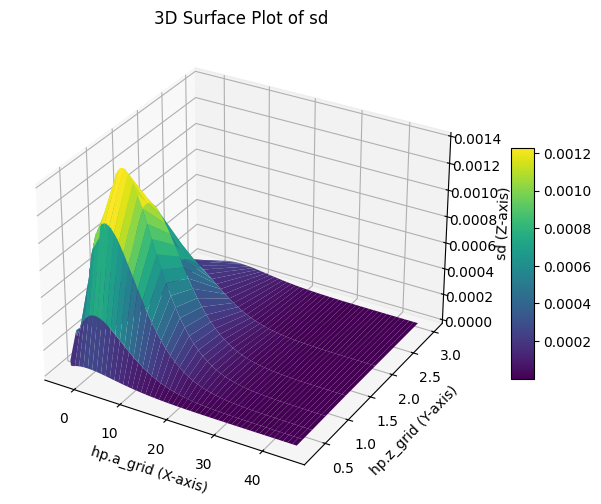

In [10]:
# 定常分布 sd のプロット
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

a_grid_sd = np.linspace(-hp.b, hp.a_grid[-1], hp.na_sd)

# メッシュグリッドを作成
X, Y = np.meshgrid(a_grid_sd, hp.z_grid)
Z = result.sd.T  # データの形状を合わせるため転置（必要なら）

# 3Dプロット
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# 軸ラベル
ax.set_xlabel('hp.a_grid (X-axis)')
ax.set_ylabel('hp.z_grid (Y-axis)')
ax.set_zlabel('sd (Z-axis)')
ax.set_title('3D Surface Plot of sd')

plt.show()

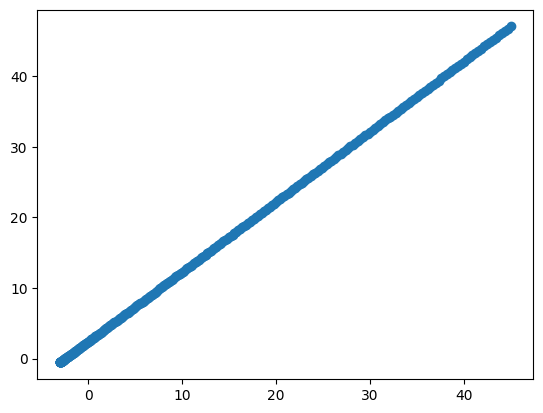

In [11]:
import pandas as pd
# hp.a_grid と hfun_a[0]のデータフレームを作る
df = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': result.hfun_a[:, -1]})
# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')